In [40]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [41]:
def load_data(path):
    return pd.read_csv(path)

df_main  = load_data('(c)Dot_Matrix_Data(DDS_only_11022020(syed)(working).csv')
df_corr  = load_data('(c)Dot_Matrix_Corrections(Sheet1).csv')
df_power = load_data('(c)Dot_Matrix_PowerActive(in).csv')
df_dpi   = load_data('(c)Dot_Matrix_printDPI_breakup(DDS).csv')

df_main_raw = df_main.copy()

print('Main:', df_main.shape)
print('Corrections:', df_corr.shape)
print('Power:', df_power.shape)
print('DPI breakup:', df_dpi.shape)

Main: (81, 16)
Corrections: (7, 28)
Power: (115, 4)
DPI breakup: (115, 4)


In [42]:
def explore(df, name):
    print('Shape:', df.shape)
    print(df.head())
    print()
    print('Nulls:')
    print(df.isnull().sum())
    print()
    print(df.describe())
    print()

explore(df_main, 'Main Data')

Shape: (81, 16)
     guid     make                model  hasA3  hasA4 dateIntroduced  \
0  OK0019      Oki                ML320  False   True            NaN   
1  OK0005      Oki                ML420  False  False            NaN   
2  LM0143  Lexmark            2391 Plus   True  False       4/9/1973   
3  LM0271  Lexmark  Forms Printer 2581+  False  False      1/20/2012   
4  LM0272  Lexmark  Forms Printer 2590+  False  False      1/20/2012   

   economode  connLocal  width  depth  height  weight  speedMono  printDPI  \
0      False       True  15.67  13.58    5.79   17.20       62.5     0.144   
1      False       True  15.70  13.60    6.00   13.00       95.0     0.144   
2      False      False  19.60  11.30    7.50   19.62      300.0     0.360   
3      False       True  24.90  11.40    7.70   21.60      618.0     0.096   
4      False       True  19.40  11.40    7.70   17.60      556.0     0.360   

   RMPVMax  listpricecurrent  
0        0            499.00  
1        0          

In [43]:

corrections = {'OK0083': {'speedMono': 150},'OK0085': {'speedMono': 200},'AD0002': {'hasA3': True, 'hasA4': True},'TG0024': {'hasA3': True, 'hasA4': True},
'EP0061': {'listpricecurrent': 1699.38},'EP0325': {'hasA4': True, 'speedMono': 56, 'listpricecurrent': 883.96},}

def apply_corrections(df, corr_map):
    df = df.copy()
    for guid, fixes in corr_map.items():
        mask = df['guid'] == guid
        if mask.sum() == 0:
            print('guid not found:', guid)
            continue
        for col, val in fixes.items():
            old = df.loc[mask, col].values[0]
            df.loc[mask, col] = val
            print(guid, '- ', col, ':', old, 'to', val)
    return df

df_main = apply_corrections(df_main_raw, corrections)

OK0083 -  speedMono : 600.0 to 150
OK0085 -  speedMono : 800.0 to 200
AD0002 -  hasA3 : False to True
AD0002 -  hasA4 : False to True
TG0024 -  hasA3 : False to True
TG0024 -  hasA4 : False to True
EP0061 -  listpricecurrent : 4502.24 to 1699.38
EP0325 -  hasA4 : True to True
EP0325 -  speedMono : 300.0 to 56
EP0325 -  listpricecurrent : 9036.53 to 883.96


In [44]:
def merge_power(df, df_power):
    pw = df_power[['guid', 'powerActive']].copy()
    merged = pd.merge(df, pw, on='guid', how='left')
    print('After power merge:', merged.shape)
    print('powerActive nulls:', merged['powerActive'].isnull().sum())
    return merged

df_main = merge_power(df_main, df_power)

After power merge: (81, 17)
powerActive nulls: 0


In [45]:
def split_dpi_col(series):
    s = series.astype(str).str.strip().str.upper()
    parts = s.str.split('X')
    x = pd.to_numeric(parts.str[0].str.strip(), errors='coerce').fillna(0).astype(float)
    y = pd.to_numeric(parts.str[1].str.strip(), errors='coerce')
    y = y.where(y.notna(), x)
    return x, y.astype(float)

def merge_dpi(df, df_dpi):
    dpi = df_dpi[['guid', 'printDPI']].copy()
    dpi['dpi_x'], dpi['dpi_y'] = split_dpi_col(dpi['printDPI'])
    dpi = dpi.drop(columns=['printDPI'])
    merged = pd.merge(df, dpi, on='guid', how='left')
    merged = merged.drop(columns=['printDPI'])
    print( merged.shape)
    print('dpi_x nulls:', merged['dpi_x'].isnull().sum())
    print('dpi_y nulls:', merged['dpi_y'].isnull().sum())
    return merged

df_main = merge_dpi(df_main, df_dpi)

(81, 18)
dpi_x nulls: 0
dpi_y nulls: 0


In [46]:
def clean_col_names(df):
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
    return df

def strip_string_cols(df):
    for c in df.select_dtypes(include=['object']).columns:
        df[c] = df[c].str.strip()
    return df

def clean_main(df):
    df = clean_col_names(df)
    df = strip_string_cols(df)
    df = df.drop(columns=['model', 'dateintroduced'], errors='ignore')
    df = df.drop_duplicates()
    return df

df_main = clean_main(df_main)
print(df_main.shape)
print(df_main.dtypes)

(81, 16)
guid                    str
make                    str
hasa3                  bool
hasa4                  bool
economode              bool
connlocal              bool
width               float64
depth               float64
height              float64
weight              float64
speedmono           float64
rmpvmax               int64
listpricecurrent    float64
poweractive           int64
dpi_x               float64
dpi_y               float64
dtype: object


C:\Users\harshit.s.p\AppData\Local\Temp\ipykernel_32588\3760848294.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include=['object']).columns:


In [47]:
def check_nulls_and_zeroes(df):
    print('Null counts')
    print(df.isnull().sum())
    print()
    print('Zero count')
    num_cols = df.select_dtypes(include=[np.number]).columns
    for c in num_cols:
        zeros = (df[c] == 0).sum()
        if zeros > 0:
            print(c, 'has', zeros, 'zeroes')
    return num_cols

num_cols = check_nulls_and_zeroes(df_main)

Null counts
guid                0
make                0
hasa3               0
hasa4               0
economode           0
connlocal           0
width               0
depth               0
height              0
weight              0
speedmono           0
rmpvmax             0
listpricecurrent    0
poweractive         0
dpi_x               0
dpi_y               0
dtype: int64

Zero count
speedmono has 1 zeroes
rmpvmax has 58 zeroes
poweractive has 15 zeroes
dpi_x has 5 zeroes
dpi_y has 5 zeroes


In [48]:
def fill_na(df, col):
    med = df[col].median()
    print('imputing', col, 'NA with median:', round(med, 4))
    df[col] = df[col].fillna(med)
    return df

def impute_all_nas(df, num_cols):
    for c in num_cols:
        if df[c].isnull().sum() > 0:
            df = fill_na(df, c)
    print()
    print('NAs after imputation:')
    print(df.isnull().sum())
    return df

df_main = impute_all_nas(df_main, num_cols)


NAs after imputation:
guid                0
make                0
hasa3               0
hasa4               0
economode           0
connlocal           0
width               0
depth               0
height              0
weight              0
speedmono           0
rmpvmax             0
listpricecurrent    0
poweractive         0
dpi_x               0
dpi_y               0
dtype: int64


In [49]:
def get_outlier_count(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    low  = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    count = ((df[col] < low) | (df[col] > high)).sum()
    print(col, ':', count, 'outliers')

def detect_outliers(df, num_cols):
    for c in num_cols:
        get_outlier_count(df, c)

detect_outliers(df_main, num_cols)

width : 0 outliers
depth : 0 outliers
height : 15 outliers
weight : 10 outliers
speedmono : 1 outliers
rmpvmax : 3 outliers
listpricecurrent : 13 outliers
poweractive : 9 outliers
dpi_x : 5 outliers
dpi_y : 0 outliers


In [50]:
def sanity_checks(df):
    print('total rows:', len(df))
    print('unique guids:', df['guid'].nunique())
    print('zero prices:', (df['listpricecurrent'] == 0).sum())
    print('negative prices:', (df['listpricecurrent'] < 0).sum())
    print()
    print(df['make'].value_counts())
    print()
    for c in df.select_dtypes(include=['bool']).columns:
        print(c, '-', df[c].value_counts().to_dict())

sanity_checks(df_main)

total rows: 81
unique guids: 81
zero prices: 0
negative prices: 0

make
Epson            30
Oki              27
Lexmark          15
TallyGenicom      3
Panasonic         2
IBM               1
AMT Datasouth     1
Printek           1
Fujitsu           1
Name: count, dtype: int64

hasa3 - {False: 71, True: 10}
hasa4 - {False: 55, True: 26}
economode - {False: 67, True: 14}
connlocal - {True: 51, False: 30}


In [51]:
def check_high_correlation(corr, threshold=0.8):
    cols = corr.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            val = corr.iloc[i, j]
            if abs(val) > threshold:
                print(cols[i], '&', cols[j], ':', round(val, 3))

def correlation_analysis(df, num_cols):
    corr = df[num_cols].corr()
    print(corr)
    print()
    check_high_correlation(corr)
    return corr

corr = correlation_analysis(df_main, num_cols)

                     width     depth    height    weight  speedmono   rmpvmax  \
width             1.000000  0.378361  0.708037  0.720267   0.216552  0.034151   
depth             0.378361  1.000000  0.440554  0.469620   0.043487  0.295173   
height            0.708037  0.440554  1.000000  0.859914   0.092195  0.040058   
weight            0.720267  0.469620  0.859914  1.000000  -0.046042  0.206760   
speedmono         0.216552  0.043487  0.092195 -0.046042   1.000000 -0.227937   
rmpvmax           0.034151  0.295173  0.040058  0.206760  -0.227937  1.000000   
listpricecurrent  0.523723  0.431922  0.574795  0.767588  -0.180219  0.352467   
poweractive       0.396899  0.147732  0.570272  0.649734  -0.206306  0.048564   
dpi_x             0.079282  0.117636 -0.026738 -0.076072   0.047001  0.038471   
dpi_y             0.064987  0.182848 -0.068215 -0.071895  -0.094855  0.152847   

                  listpricecurrent  poweractive     dpi_x     dpi_y  
width                     0.523723    

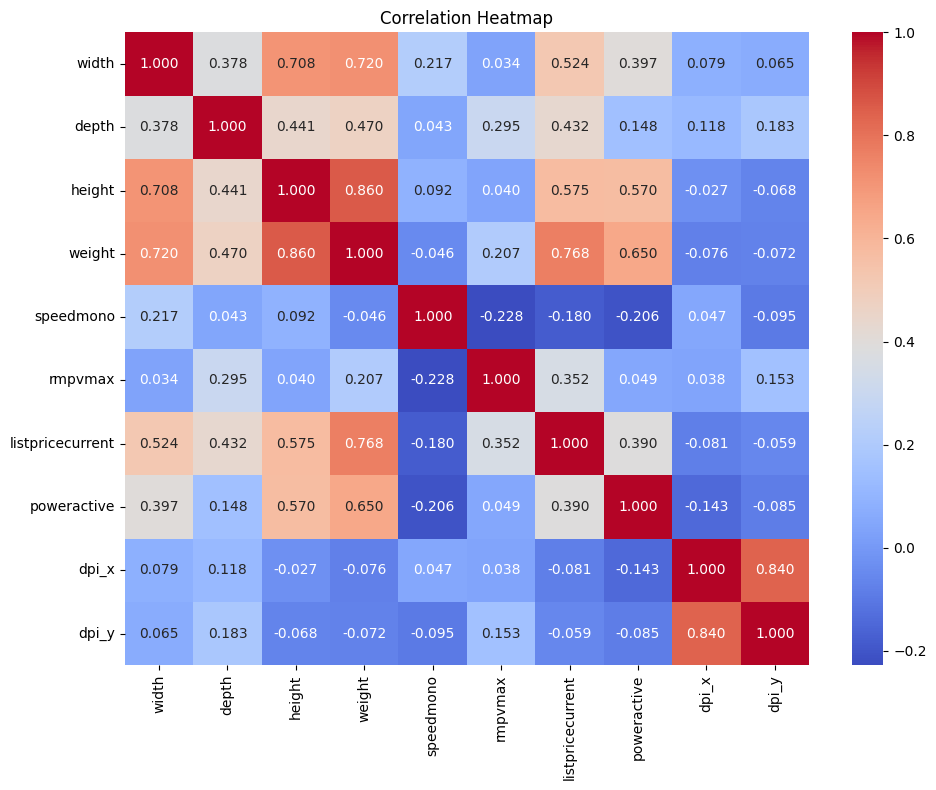

In [52]:
def plot_heatmap(corr):
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm')
    plt.title('Correlation Heatmap')
    plt.tight_layout()
    plt.show()

plot_heatmap(corr)

In [53]:
def prepare_model_data(df):
    cat_cols = df.select_dtypes(include=['object']).columns.tolist()
    cat_cols = [c for c in cat_cols if c != 'guid']
    bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
    df_model = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)
    for c in bool_cols:
        df_model[c] = df_model[c].astype(int)
    df_model = df_model.drop(columns=['guid'], errors='ignore')
    print('Model dataframe shape:', df_model.shape)
    print('Columns:', df_model.columns.tolist())
    return df_model

df_model = prepare_model_data(df_main)

Model dataframe shape: (81, 22)
Columns: ['hasa3', 'hasa4', 'economode', 'connlocal', 'width', 'depth', 'height', 'weight', 'speedmono', 'rmpvmax', 'listpricecurrent', 'poweractive', 'dpi_x', 'dpi_y', 'make_Epson', 'make_Fujitsu', 'make_IBM', 'make_Lexmark', 'make_Oki', 'make_Panasonic', 'make_Printek', 'make_TallyGenicom']


C:\Users\harshit.s.p\AppData\Local\Temp\ipykernel_32588\1818940890.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


In [54]:
def split_data(df_model, target='listpricecurrent', test_size=0.30, seed=42):
    y = df_model[target]
    X = df_model.drop(columns=[target])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)
    print('train:', X_train.shape[0], 'test:', X_test.shape[0])
    return X, X_train, X_test, y_train, y_test

X, X_train, X_test, y_train, y_test = split_data(df_model)

train: 56 test: 25


In [55]:
def train_and_evaluate(X_train, X_test, y_train, y_test):
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)
    print('Train R2  :', round(r2_score(y_train, y_train_pred), 4))
    print('Test  R2  :', round(r2_score(y_test,  y_test_pred),  4))
    print('Train RMSE:', round(np.sqrt(mean_squared_error(y_train, y_train_pred)), 2))
    print('Test  RMSE:', round(np.sqrt(mean_squared_error(y_test,  y_test_pred)),  2))
    return model, y_train_pred, y_test_pred

model, y_train_pred, y_test_pred = train_and_evaluate(X_train, X_test, y_train, y_test)

Train R2  : 0.8757
Test  R2  : 0.1849
Train RMSE: 245.79
Test  RMSE: 472.94


In [56]:
def show_coefficients(model, X):
    coeff = pd.DataFrame({'feature': X.columns, 'coefficient': model.coef_})
    coeff = coeff.sort_values('coefficient', ascending=False).reset_index(drop=True)
    print('intercept:', round(model.intercept_, 4))
    print(coeff)

show_coefficients(model, X)

intercept: -259.2246
              feature  coefficient
0           connlocal   474.898102
1      make_Panasonic   337.570625
2               hasa4   334.748227
3               hasa3   319.940217
4   make_TallyGenicom   299.023008
5          make_Epson   251.522881
6        make_Lexmark   212.224185
7        make_Fujitsu   104.067023
8            make_Oki    94.956333
9              weight    40.683664
10              width    18.942336
11              dpi_x     0.825761
12            rmpvmax     0.014252
13          speedmono    -0.999526
14        poweractive    -1.113504
15              dpi_y    -1.186617
16              depth   -18.938570
17             height   -33.454493
18           make_IBM   -67.354364
19          economode  -163.262007
20       make_Printek -1232.009689


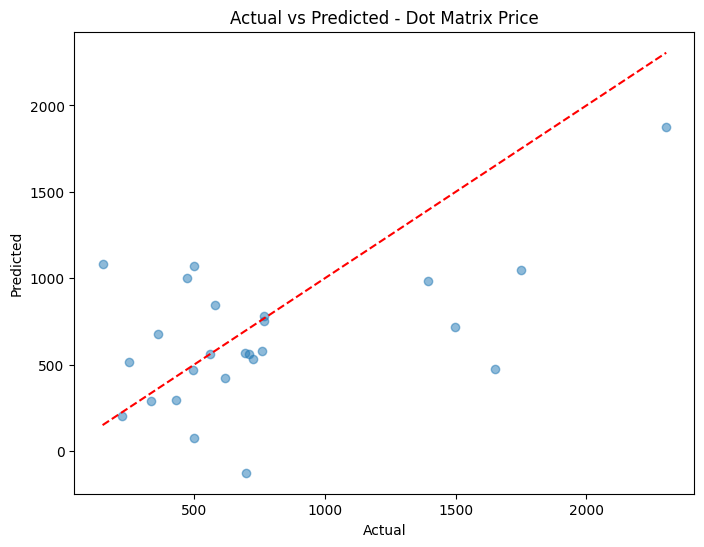

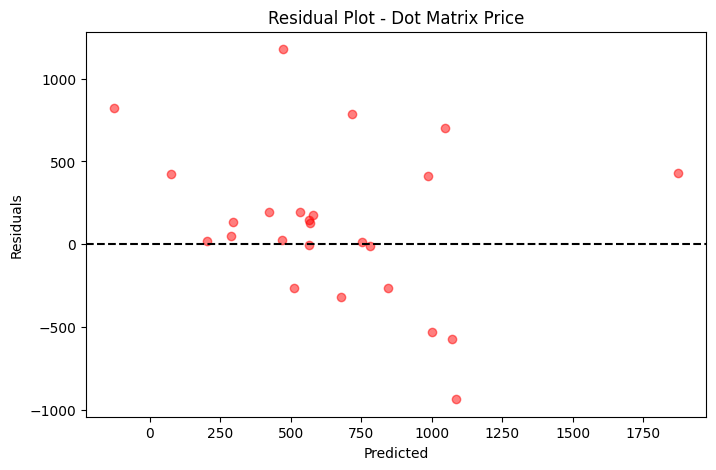

In [57]:
def plot_actual_vs_predicted(y_test, y_test_pred):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_test_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('Actual vs Predicted - Dot Matrix Price')
    plt.show()

def plot_residuals(y_test, y_test_pred):
    residuals = y_test - y_test_pred
    plt.figure(figsize=(8, 5))
    plt.scatter(y_test_pred, residuals, alpha=0.5, color='red')
    plt.axhline(y=0, color='black', linestyle='--')
    plt.xlabel('Predicted')
    plt.ylabel('Residuals')
    plt.title('Residual Plot - Dot Matrix Price')
    plt.show()

plot_actual_vs_predicted(y_test, y_test_pred)
plot_residuals(y_test, y_test_pred)